# Unidad 3 · CLSP: las extensiones, una a una

**Planta:** Conservas del Itata S.A.
**Datos:** `DatosClases/3_Planificacion/Planificiacion/` — la MISMA instancia del cuaderno 02
**Solver:** Gurobi

---

## Qué se decide aquí

El CLSP del cuaderno 02 es un modelo de laboratorio: no deja diferir un
pedido, no permite pagar una hora extra, no obliga a tener nada en bodega por
si acaso y supone que lo que se produce el lunes está disponible el lunes.
Ninguna de esas cuatro cosas es cierta en la planta.

Aquí se agregan, **una a la vez y sobre la misma instancia**, cinco
extensiones:

| extensión | qué cambia en el modelo |
|---|---|
| **horas extra** | una variable `o[r,t] ≥ 0` que compra capacidad a un precio por hora |
| **backlog** | una variable `B[i,t] ≥ 0` que permite entregar tarde pagando penalización |
| **stock de seguridad** | una cota inferior al inventario, **dura** o **blanda** |
| **lead time** | lo iniciado en `t` recién sirve en `t + L_i` |
| **costo de arranque** | *start-up*: se paga cuando la corrida **empieza**, no cada vez que hay lote |

Que sea sobre la misma instancia no es una formalidad: es la única forma de
que la diferencia de costo sea atribuible al **modelo** y no a los datos.
Comparar el modelo A sobre la planta de 2024 con el modelo B sobre la planta
de 2025 y concluir que "B es mejor" es el error más común de los informes de
esta unidad.

## La lección central del cuaderno

No es ninguna de las cinco extensiones. Es esto:

> **El big-M ajustado del cuaderno 02 deja de ser válido si se permite
> backlog.**

Sin backlog nunca conviene producir en `t` más que la demanda de `t` en
adelante: lo anterior ya se sirvió. Con backlog eso es **falso** —parte de la
demanda de semanas anteriores puede seguir pendiente y hay que producirla— y
la cota recorta soluciones factibles.

El síntoma es venenoso: el modelo **no falla**. No hay infactibilidad, no hay
advertencia, el solver dice `OPTIMAL` y entrega un plan. Solo que ese plan
cuesta **más** que el óptimo verdadero. La sección 6 lo demuestra
numéricamente.

## Cifras de referencia

| modelo | objetivo (CLP) | preparaciones |
|---|---|---|
| básico (cuaderno 02) | 16 457 114 | 34 |
| + horas extra | 16 247 378 | 32 |
| + backlog | **15 772 683** | 32 |
| + stock de seguridad (blando), lead time e inventario final | 20 100 279 | 34 |

| comparación | valor |
|---|---|
| óptimo verdadero (cota válida con backlog) | **16 148 005** |
| "óptimo" con la cota inválida | **16 152 894** ← mayor, y el solver dice OPTIMAL |
| costo de arranque: sin start-up | 30 preparaciones, 0 arranques |
| costo de arranque: con start-up | 43 preparaciones, 7 arranques |

In [1]:
import sys
import time
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB

from comun import datos, tabla, figura, resumen, verificar, estilo

estilo()

dem = pd.read_csv(datos("3_Planificacion", "itata_demanda_plan.csv"))
par = pd.read_csv(datos("3_Planificacion", "itata_parametros_sku.csv"))
cap = pd.read_csv(datos("3_Planificacion", "itata_capacidad.csv"))
tas = pd.read_csv(datos("3_Planificacion", "itata_tasas.csv"))
ini = pd.read_csv(datos("3_Planificacion", "itata_inventario_inicial.csv"))

SKUS = list(par.sku)
T = sorted(dem.t.unique().tolist())
REC = sorted(cap.recurso.unique().tolist())
p = par.set_index("sku")

demanda = {(r.sku, int(r.t)): float(r.demanda_cajas) for _, r in dem.iterrows()}
costo_setup = {i: float(p.loc[i, "costo_setup_clp"]) for i in SKUS}
costo_almacen = {i: float(p.loc[i, "costo_almacen_clp_caja_sem"]) for i in SKUS}
costo_backlog = {i: float(p.loc[i, "costo_backlog_clp_caja_sem"]) for i in SKUS}
costo_prod = {i: float(p.loc[i, "costo_unitario_clp_caja"]) for i in SKUS}
stock_seg = {i: float(p.loc[i, "stock_seguridad_cajas"]) for i in SKUS}
lead = {i: int(p.loc[i, "lead_time_sem"]) for i in SKUS}
inv_final_min = dict(stock_seg)

# el autoclave se recalienta desde frio: arrancar una corrida cuesta bastante
# mas que mantenerla andando de una semana a la siguiente
costo_arranque = {i: round(1.6 * costo_setup[i]) for i in SKUS}
# estado de la planta al comenzar el horizonte: no venia produciendo nada
producia_antes = {i: 0 for i in SKUS}

_ini = dict(zip(ini["item"], ini.inventario_inicial.astype(float)))   # df["item"], no df.item
inv_ini = {i: _ini.get(i, 0.0) for i in SKUS}

linea = dict(zip(tas.sku, tas.linea))
consumo = {}
for _, r in tas.iterrows():
    consumo[(r.sku, "PREP")] = float(r.h_por_caja_PREP)
    consumo[(r.sku, "AUT")] = float(r.h_por_caja_AUT)
    consumo[(r.sku, r.linea)] = float(r.h_por_caja_linea)
tiempo_setup = {(r.sku, linea[r.sku]): float(r.tiempo_setup_h) for _, r in par.iterrows()}

capacidad = {(r.recurso, int(r.t)): float(r.horas_disponibles) for _, r in cap.iterrows()}
extra_max = {(r.recurso, int(r.t)): float(r.horas_extra_max) for _, r in cap.iterrows()}
costo_extra = {(r.recurso, int(r.t)): float(r.costo_hora_extra_clp) for _, r in cap.iterrows()}

print(par[["sku", "costo_backlog_clp_caja_sem", "lead_time_sem",
           "stock_seguridad_cajas"]].to_string(index=False))
print("\ncosto de arranque de corrida (1,6 x el setup):",
      {i: f"{costo_arranque[i]:,}" for i in SKUS})

     sku  costo_backlog_clp_caja_sem  lead_time_sem  stock_seguridad_cajas
 DUR-480                       737.0              0                  269.0
 DUR-820                      1094.5              0                   58.0
 TOM-480                       478.5              0                  792.0
TOM-3000                      1732.5              1                  128.0
 POR-480                       665.5              0                  266.0
POR-3000                      2101.0              1                   40.0

costo de arranque de corrida (1,6 x el setup): {'DUR-480': '616,000', 'DUR-820': '707,200', 'TOM-480': '476,800', 'TOM-3000': '825,600', 'POR-480': '577,600', 'POR-3000': '876,800'}


## 1. El big-M, ahora con interruptor

Es la misma función del cuaderno 02, con la rama `con_backlog` activada.
Vale la pena leerla entera antes de seguir, porque toda la sección 6 depende
de esas cuatro líneas.

* **Sin backlog:** `resto = Σ_{u ≥ t} d_iu`. Producir más que eso es
  imposible de consumir.
* **Con backlog:** cualquier demanda del horizonte puede seguir pendiente,
  así que lo único que se puede afirmar es
  `resto = Σ_{u} d_iu − I_i0`. Es una cota **mucho** más floja, y es el
  precio de admitir backlog.

La cota física no cambia: la planta no se agranda porque se permita entregar
tarde. Aquí sí se cuentan las horas extra, porque varias variantes las usan.

In [2]:
def big_M(i, t, con_backlog=False):
    """Cota superior valida para la produccion de i en t.

    ``con_backlog`` NO es un adorno. Ver la seccion 6.
    """
    if con_backlog:
        resto = sum(demanda[(i, u)] for u in T) - inv_ini[i]
    else:
        resto = sum(demanda[(i, u)] for u in T if u >= t)
    resto = max(0.0, resto) + stock_seg[i] + inv_final_min[i]

    fisico = float("inf")
    for r in REC:
        a = consumo.get((i, r), 0.0)
        if a <= 0:
            continue
        horas = capacidad.get((r, t), 0.0) + extra_max.get((r, t), 0.0) \
            - tiempo_setup.get((i, r), 0.0)
        fisico = min(fisico, max(0.0, horas) / a)
    return float(min(resto, fisico))


cmp_M = pd.DataFrame([{"sku": i, "t": t,
                       "M_sin_backlog": big_M(i, t, False),
                       "M_con_backlog": big_M(i, t, True)}
                      for i in SKUS for t in (1, 6, 12)])
cmp_M["razon"] = cmp_M.M_con_backlog / cmp_M.M_sin_backlog
print(cmp_M.to_string(index=False, float_format=lambda v: f"{v:,.2f}"))
print("\nAl final del horizonte la diferencia es brutal: sin backlog la cota de")
print("t=12 es casi solo la demanda de esa semana; con backlog hay que admitir")
print("que podria estar pendiente la demanda de las doce.")

     sku  t  M_sin_backlog  M_con_backlog  razon
 DUR-480  1       8,385.00       8,385.00   1.00
 DUR-480  6       7,187.50       7,187.50   1.00
 DUR-480 12       2,139.00       7,145.07   3.34
 DUR-820  1       2,829.38       2,829.38   1.00
 DUR-820  6       2,350.00       2,829.38   1.20
 DUR-820 12         447.00       2,141.38   4.79
 TOM-480  1       8,416.00       8,416.00   1.00
 TOM-480  6       7,187.50       7,187.50   1.00
 TOM-480 12       4,379.00       7,176.07   1.64
TOM-3000  1       1,434.42       1,434.42   1.00
TOM-3000  6       1,434.42       1,434.42   1.00
TOM-3000 12         575.00       1,082.41   1.88
 POR-480  1       8,385.00       8,385.00   1.00
 POR-480  6       6,776.00       7,187.50   1.06
 POR-480 12       1,301.00       7,145.07   5.49
POR-3000  1       1,359.00       1,318.00   0.97
POR-3000  6         738.00       1,318.00   1.79
POR-3000 12         161.00       1,078.01   6.70

Al final del horizonte la diferencia es brutal: sin backlog la cota 

## 2. El modelo, con todas las extensiones como banderas

$$
\begin{aligned}
\min \quad & \sum_{i,t} \big( K_i y_{it} + A_i \alpha_{it} + h_i I_{it}
  + b_i B_{it} + \pi_i u_{it} \big) + \sum_{r,t} ce_{rt}\, o_{rt} \\
\text{s.a.}\quad
& I_{i,t-1} - B_{i,t-1} + x_{i,t-L_i} - d_{it} = I_{it} - B_{it} && \forall i,t \\
& x_{it} \le M_{it}\, y_{it} && \forall i,t \\
& \alpha_{it} \ge y_{it} - y_{i,t-1} && \forall i,t \quad (\text{arranque}) \\
& \sum_i \big( a_{ir} x_{it} + s_{ir} y_{it} \big) \le \text{cap}_{rt} + o_{rt} && \forall r,t \\
& o_{rt} \le \overline{o}_{rt},\qquad I_{it} + u_{it} \ge ss_i && \\
& B_{i,|T|} = 0,\qquad I_{i,|T|} \ge ss_i &&
\end{aligned}
$$

Cuatro decisiones de modelado que conviene justificar en voz alta:

**El backlog debe cerrarse al final.** `B[i,|T|] = 0`. Si no, el modelo
descubre que la forma más barata de planificar doce semanas es no producir y
deber todo: el horizonte se acaba y nadie cobra.

**El inventario final debe respetar el stock de seguridad.** Es el mismo
efecto de fin de horizonte por el otro lado: sin esa restricción el modelo
vacía la bodega en la semana 12 y entrega un plan que deja a la planta con
cero cobertura el lunes siguiente.

**El stock de seguridad puede ser duro o blando.** Duro (`I ≥ ss`) es una
restricción; blando (`I + u ≥ ss`, con `u` penalizado) es un objetivo. En
esta instancia el stock duro es **infactible**: la capacidad no alcanza para
sostener la cobertura todas las semanas. Que sea infactible es *información*,
no un error, y es exactamente la razón por la que se modela blando.

**Con lead time, lo iniciado en las últimas `L_i` semanas no alcanza a
servir.** Hay que prohibirlo explícitamente (`x[i,t] = 0` para
`t > |T| − L_i`) o el modelo produce cajas que llegan después del horizonte y
aun así las cuenta.

In [3]:
def clsp(horas_extra=False, backlog=False, stock_seguridad="ninguno",
         lead_time=False, inventario_final_minimo=False, start_up=False,
         cota_backlog="valida", big_M_generico=None,
         penal_ss=5.0, tiempo_limite=180.0, gap=1e-4, verbose=False):
    """CLSP con extensiones activables.

    ``cota_backlog`` elige el big-M cuando hay backlog:
      'valida'   -> big_M(i, t, con_backlog=True)   (correcto)
      'invalida' -> big_M(i, t, con_backlog=False)  (la trampa de la seccion 6)
    """
    m = gp.Model("CLSP-ext")
    m.Params.OutputFlag = 1 if verbose else 0
    m.Params.TimeLimit = tiempo_limite
    m.Params.MIPGap = gap
    m.Params.Seed = 0

    L = {i: (lead[i] if lead_time else 0) for i in SKUS}

    x = m.addVars(SKUS, T, lb=0.0, name="x")
    y = m.addVars(SKUS, T, vtype=GRB.BINARY, name="y")
    I = m.addVars(SKUS, T, lb=0.0, name="I")
    B = (m.addVars(SKUS, T, lb=0.0, name="B") if backlog
         else {(i, t): 0.0 for i in SKUS for t in T})
    o = (m.addVars(REC, T, lb=0.0, name="o") if horas_extra
         else {(r, t): 0.0 for r in REC for t in T})
    u = (m.addVars(SKUS, T, lb=0.0, name="u") if stock_seguridad == "blando"
         else {(i, t): 0.0 for i in SKUS for t in T})
    alfa = (m.addVars(SKUS, T, vtype=GRB.BINARY, name="arranque") if start_up
            else {(i, t): 0.0 for i in SKUS for t in T})

    # --- balance con backlog y lead time
    for i in SKUS:
        for k, t in enumerate(T):
            prev_I = inv_ini[i] if k == 0 else I[i, T[k - 1]]
            prev_B = 0.0 if k == 0 else B[i, T[k - 1]]
            kk = k - L[i]
            llega = x[i, T[kk]] if kk >= 0 else 0.0
            m.addConstr(prev_I - prev_B + llega - demanda[(i, t)] == I[i, t] - B[i, t],
                        name=f"bal[{i},{t}]")
        if backlog:
            m.addConstr(B[i, T[-1]] == 0.0, name=f"sin_backlog_final[{i}]")
        # lo iniciado en las ultimas L_i semanas no alcanza a servir
        for k in range(len(T) - L[i], len(T)):
            if k >= 0 and L[i] > 0:
                m.addConstr(x[i, T[k]] == 0.0, name=f"fuera_horizonte[{i},{T[k]}]")

    # --- enlace produccion - preparacion
    M = {}
    for i in SKUS:
        for t in T:
            if big_M_generico:
                M[i, t] = big_M_generico
            elif backlog and cota_backlog == "invalida":
                M[i, t] = big_M(i, t, con_backlog=False)     # <-- cota NO valida
            else:
                M[i, t] = big_M(i, t, con_backlog=backlog)
            m.addConstr(x[i, t] <= M[i, t] * y[i, t], name=f"enl[{i},{t}]")

    # --- arranque de corrida (start-up)
    if start_up:
        for i in SKUS:
            for k, t in enumerate(T):
                previo = producia_antes[i] if k == 0 else y[i, T[k - 1]]
                m.addConstr(alfa[i, t] >= y[i, t] - previo, name=f"arr[{i},{t}]")

    # --- capacidad, con horas extra
    for r in REC:
        for t in T:
            m.addConstr(
                gp.quicksum(consumo.get((i, r), 0.0) * x[i, t]
                            + tiempo_setup.get((i, r), 0.0) * y[i, t] for i in SKUS)
                <= capacidad[(r, t)] + o[r, t], name=f"cap[{r},{t}]")
            if horas_extra:
                m.addConstr(o[r, t] <= extra_max[(r, t)], name=f"omax[{r},{t}]")

    # --- stock de seguridad
    if stock_seguridad != "ninguno":
        for i in SKUS:
            if stock_seg[i] <= 0:
                continue
            for t in T:
                if stock_seguridad == "duro":
                    m.addConstr(I[i, t] >= stock_seg[i], name=f"ss[{i},{t}]")
                else:
                    m.addConstr(I[i, t] + u[i, t] >= stock_seg[i], name=f"ss[{i},{t}]")

    if inventario_final_minimo:
        for i in SKUS:
            if inv_final_min[i] > 0:
                m.addConstr(I[i, T[-1]] >= inv_final_min[i], name=f"invfin[{i}]")

    # --- objetivo (el costo variable de produccion se reporta aparte)
    c_setup = gp.quicksum(costo_setup[i] * y[i, t] for i in SKUS for t in T)
    c_alm = gp.quicksum(costo_almacen[i] * I[i, t] for i in SKUS for t in T)
    c_arr = (gp.quicksum(costo_arranque[i] * alfa[i, t] for i in SKUS for t in T)
             if start_up else 0.0)
    c_back = (gp.quicksum(costo_backlog[i] * B[i, t] for i in SKUS for t in T)
              if backlog else 0.0)
    c_extra = (gp.quicksum(costo_extra[(r, t)] * o[r, t] for r in REC for t in T)
               if horas_extra else 0.0)
    c_ss = (gp.quicksum(penal_ss * costo_almacen[i] * u[i, t] for i in SKUS for t in T)
            if stock_seguridad == "blando" else 0.0)

    m.setObjective(c_setup + c_alm + c_arr + c_back + c_extra + c_ss, GRB.MINIMIZE)

    # relajacion lineal, para reportar el gap en la raiz
    m.update()
    rel = m.relax()
    rel.Params.OutputFlag = 0
    rel.optimize()
    cota_lp = rel.ObjVal if rel.Status == GRB.OPTIMAL else None

    m.optimize()
    return m, {"x": x, "y": y, "I": I, "B": B, "o": o, "u": u, "alfa": alfa,
               "M": M, "cota_lp": cota_lp,
               "costos": {"setup": c_setup, "almacenamiento": c_alm,
                          "arranque": c_arr, "backlog": c_back,
                          "horas extra": c_extra, "penal. stock seg.": c_ss}}


ESTADO = {GRB.OPTIMAL: "OPTIMAL", GRB.TIME_LIMIT: "TIME_LIMIT",
          GRB.INFEASIBLE: "INFEASIBLE", GRB.INF_OR_UNBD: "INF_OR_UNBD"}


def informar(nombre, m, v, mostrar=True):
    """Fila de resultados con todo lo que la pauta exige reportar."""
    val = lambda e: e.getValue() if hasattr(e, "getValue") else float(e)
    fila = {"modelo": nombre, "estado": ESTADO.get(m.Status, str(m.Status))}
    if m.SolCount == 0:
        fila.update({"objetivo": np.nan, "setups": 0})
        if mostrar:
            print(f"{nombre:38s} {fila['estado']}  (sin solucion)")
        return fila
    setups = int(round(sum(v["y"][i, t].X for i in SKUS for t in T)))
    arr = int(round(sum(v["alfa"][i, t].X if hasattr(v["alfa"][i, t], "X") else 0.0
                        for i in SKUS for t in T)))
    fila.update({
        "objetivo": m.ObjVal, "cota": m.ObjBound, "gap_%": 100 * m.MIPGap,
        "gap_raiz_%": (100 * (m.ObjVal - v["cota_lp"]) / m.ObjVal
                       if v["cota_lp"] else np.nan),
        "setups": setups, "arranques": arr,
        "variables": m.NumVars, "binarias": m.NumBinVars,
        "restricciones": m.NumConstrs, "segundos": m.Runtime,
    })
    for k, e in v["costos"].items():
        fila[k] = val(e)
    fila["backlog_cajas"] = sum(
        v["B"][i, t].X if hasattr(v["B"][i, t], "X") else 0.0
        for i in SKUS for t in T)
    fila["horas_extra_h"] = sum(
        v["o"][r, t].X if hasattr(v["o"][r, t], "X") else 0.0
        for r in REC for t in T)
    fila["_costo_variable_excluido"] = sum(costo_prod[i] * v["x"][i, t].X
                                           for i in SKUS for t in T)
    if mostrar:
        print(f"{nombre:38s} {fila['estado']:10s} "
              f"obj {m.ObjVal:>14,.0f} | {setups:2d} setups | "
              f"gap raíz {fila['gap_raiz_%']:5.1f} % | "
              f"{m.NumVars:4d} var ({m.NumBinVars} bin) | {m.Runtime:5.1f} s")
    return fila

## 3. La escalera de extensiones

Se acumulan de a una. Cada fila difiere de la anterior en **una** bandera, y
la instancia es idéntica en las cuatro.

In [4]:
escalera = [
    ("básico (cuaderno 02)", dict()),
    ("+ horas extra", dict(horas_extra=True)),
    ("+ backlog", dict(horas_extra=True, backlog=True)),
    ("+ stock seg. blando, lead time e inv. final",
     dict(horas_extra=True, backlog=True, stock_seguridad="blando",
          lead_time=True, inventario_final_minimo=True)),
]
filas = []
for nombre, kw in escalera:
    m_, v_ = clsp(**kw)
    filas.append(informar(nombre, m_, v_))
esc = pd.DataFrame(filas)

print()
cols = ["modelo", "objetivo", "setups", "gap_raiz_%", "setup", "almacenamiento",
        "backlog", "horas extra", "penal. stock seg."]
print(esc[cols].to_string(index=False, float_format=lambda v: f"{v:,.0f}"))

Restricted license - for non-production use only - expires 2027-11-29


básico (cuaderno 02)                   OPTIMAL    obj     16,457,114 | 34 setups | gap raíz  54.2 % |  216 var (72 bin) |   0.8 s


+ horas extra                          OPTIMAL    obj     16,247,378 | 32 setups | gap raíz  53.7 % |  264 var (72 bin) |   0.6 s


+ backlog                              OPTIMAL    obj     15,772,683 | 32 setups | gap raíz  65.0 % |  336 var (72 bin) |   1.5 s


+ stock seg. blando, lead time e inv. final OPTIMAL    obj     20,100,279 | 34 setups | gap raíz  61.3 % |  408 var (72 bin) |   1.9 s

                                     modelo   objetivo  setups  gap_raiz_%      setup  almacenamiento   backlog  horas extra  penal. stock seg.
                       básico (cuaderno 02) 16,457,114      34          54 13,546,000       2,911,114         0            0                  0
                              + horas extra 16,247,378      32          54 12,482,000       3,281,293         0      484,085                  0
                                  + backlog 15,772,683      32          65 12,482,000       2,964,981   325,702            0                  0
+ stock seg. blando, lead time e inv. final 20,100,279      34          61 13,141,000       2,896,114 1,690,081      456,544          1,916,539


### Qué dice cada escalón

**Horas extra: −209 736 CLP.** El modelo gasta 484 085 CLP en horas extra
para ahorrar 1 064 000 CLP de setup. Lo relevante no es el saldo sino que
baja de 34 a 32 preparaciones: comprar capacidad en la semana apretada
permite dejar de partir un lote en dos. La hora extra no se usa para producir
más; se usa para producir **más junto**.

**Backlog: −474 695 CLP adicionales.** Diferir demanda es una válvula de
escape barata en las semanas de peak. Cuidado con la lectura: el modelo
"ahorra" porque el costo de backlog del catálogo (11 × el costo de
almacenaje) es una penalización contable, no el costo real de un cliente
perdido. Si la penalización está mal calibrada, el modelo va a diferir
alegremente pedidos que en la vida real cuestan un contrato.

**Stock de seguridad, lead time e inventario final: +4 327 596 CLP.** Este
escalón **sube** el costo, y mucho. Es el precio de la robustez: obligar a
cubrir cobertura y a producir con una semana de anticipación (TOM-3000 y
POR-3000 tienen `lead_time = 1`) consume exactamente la holgura que los
escalones anteriores habían liberado. Un informe que solo muestra los dos
primeros escalones está vendiendo un ahorro que la planta no puede tomar.

### Duro contra blando, y la pregunta que solo contesta el IIS

El escalón 4 usa stock de seguridad **blando**: se admite déficit y se
penaliza a 5 × el costo de almacenaje. La versión **dura** —`I ≥ ss` como
restricción— es una decisión distinta, y hay que resolverla para saber cuánto
cuesta.

Más interesante todavía: la dura es factible **solo porque hay backlog**. Sin
esa válvula de escape, exigir cobertura todas las semanas no tiene solución
en esta planta. Que no la tenga es *información* —es un hallazgo de
capacidad, no un fracaso del modelo— y el IIS dice exactamente qué
restricciones se contradicen.

In [5]:
COMUN_SS = dict(stock_seguridad="duro", lead_time=True,
                inventario_final_minimo=True)

m_duro, v_duro = clsp(horas_extra=True, backlog=True, **COMUN_SS, tiempo_limite=120.0)
f_duro = informar("stock de seguridad DURO (con backlog)", m_duro, v_duro)
print(f"  contra el blando del escalón 4: "
      f"{m_duro.ObjVal - float(esc.loc[3, 'objetivo']):,.0f} CLP más caro.")
print("  Esa diferencia es lo que vale poder incumplir la cobertura de vez en")
print("  cuando. Si la planta no puede incumplirla, el numero correcto es el duro.\n")

m_sinb, v_sinb = clsp(horas_extra=True, backlog=False, **COMUN_SS, tiempo_limite=120.0)
print(f"stock de seguridad DURO, SIN backlog -> "
      f"{ESTADO.get(m_sinb.Status, m_sinb.Status)}")
if m_sinb.Status == GRB.INFEASIBLE:
    m_sinb.computeIIS()
    culpables = [c.ConstrName for c in m_sinb.getConstrs() if c.IISConstr]
    print(f"  restricciones en el conjunto irreducible (IIS): {len(culpables)}")
    for c in culpables[:12]:
        print(f"    {c}")
    print("\n  El IIS es la respuesta a 'por que no hay solucion'. Sin el, lo unico")
    print("  que se puede decir es 'el solver no encontro nada', que no es lo mismo:")
    print("  lo primero es una propiedad del problema, lo segundo del tiempo de CPU.")

stock de seguridad DURO (con backlog)  OPTIMAL    obj     21,564,874 | 34 setups | gap raíz  61.0 % |  336 var (72 bin) |   3.5 s
  contra el blando del escalón 4: 1,464,594 CLP más caro.
  Esa diferencia es lo que vale poder incumplir la cobertura de vez en
  cuando. Si la planta no puede incumplirla, el numero correcto es el duro.

stock de seguridad DURO, SIN backlog -> INFEASIBLE
  restricciones en el conjunto irreducible (IIS): 1
    bal[TOM-3000,1]

  El IIS es la respuesta a 'por que no hay solucion'. Sin el, lo unico
  que se puede decir es 'el solver no encontro nada', que no es lo mismo:
  lo primero es una propiedad del problema, lo segundo del tiempo de CPU.


## 4. El gráfico: de dónde sale cada peso

La comparación honesta no es una columna de totales: es la composición. Los
escalones 2 y 3 mueven plata entre bolsillos (menos setup, más backlog) y el
escalón 4 agrega un bolsillo nuevo.

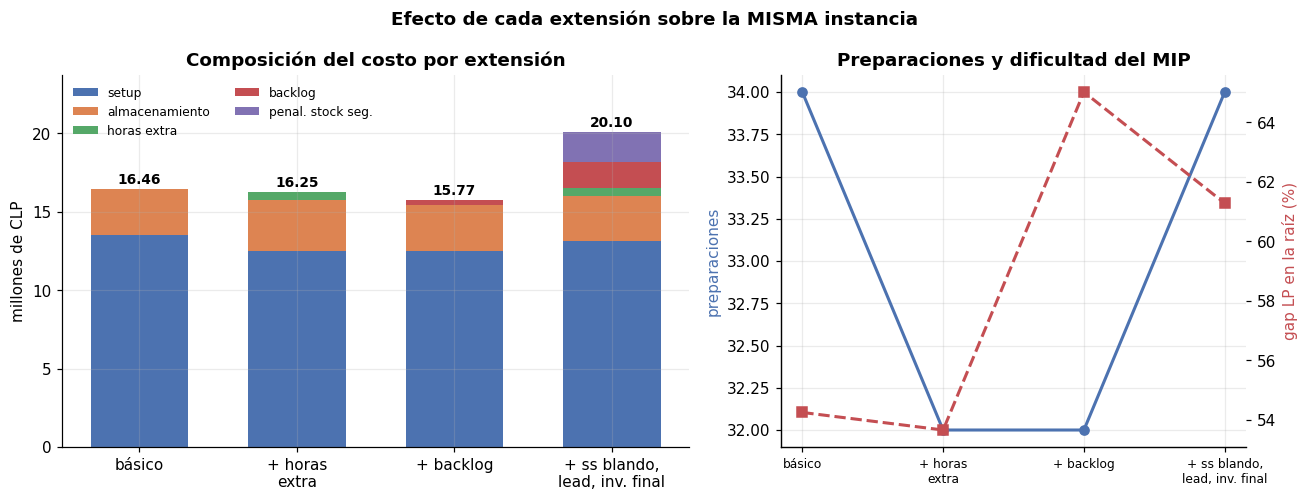

El gap en la raiz SUBE al agregar backlog (de 53,7 % a 65,0 %) y esa
subida no es casualidad: es justamente el aflojamiento del big-M que
obliga la seccion 6.


In [6]:
comps = ["setup", "almacenamiento", "horas extra", "backlog", "penal. stock seg."]
colores = ["#4c72b0", "#dd8452", "#55a868", "#c44e52", "#8172b3"]
etiquetas = ["básico", "+ horas\nextra", "+ backlog", "+ ss blando,\nlead, inv. final"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.0, 4.6),
                               gridspec_kw={"width_ratios": [1.35, 1]})
base = np.zeros(len(esc))
for comp, col in zip(comps, colores):
    val = esc[comp].fillna(0.0).to_numpy() / 1e6
    ax1.bar(etiquetas, val, bottom=base, color=col, label=comp, width=0.62)
    base += val
ax1.set_ylabel("millones de CLP")
ax1.set_title("Composición del costo por extensión")
ax1.legend(fontsize=8, ncol=2, loc="upper left")
for k, vtot in enumerate(base):
    ax1.text(k, vtot + 0.35, f"{vtot:,.2f}", ha="center", fontsize=9,
             fontweight="bold")
ax1.set_ylim(0, base.max() * 1.18)

ax2.plot(range(len(esc)), esc.setups, marker="o", lw=2, color="#4c72b0",
         label="preparaciones")
ax2b = ax2.twinx()
ax2b.plot(range(len(esc)), esc["gap_raiz_%"], marker="s", lw=2, ls="--",
          color="#c44e52", label="gap en la raíz (%)")
ax2.set_xticks(range(len(esc)))
ax2.set_xticklabels(etiquetas, fontsize=8)
ax2.set_ylabel("preparaciones", color="#4c72b0")
ax2b.set_ylabel("gap LP en la raíz (%)", color="#c44e52")
ax2b.grid(False)
ax2.set_title("Preparaciones y dificultad del MIP")
fig.suptitle("Efecto de cada extensión sobre la MISMA instancia",
             fontweight="bold")
figura(fig, "clsp_extensiones")
plt.show()

print("El gap en la raiz SUBE al agregar backlog (de 53,7 % a 65,0 %) y esa")
print("subida no es casualidad: es justamente el aflojamiento del big-M que")
print("obliga la seccion 6.")

## 5. El costo de arranque (*start-up*): un costo que premia la continuidad

El setup se cobra **cada semana** en que hay lote. El arranque se cobra solo
cuando la corrida **empieza**:

$$\alpha_{it} \ge y_{it} - y_{i,t-1}$$

Si el producto ya venía andando la semana anterior, `y_{i,t-1} = 1` y el lado
derecho es cero: el arranque no se paga. La variable `α` puede declararse
continua —su coeficiente en el objetivo es positivo y solo aparece con signo
`≥`, así que el óptimo la empuja a 0 o 1—, pero se declara binaria para poder
leerla.

La predicción intuitiva es "con un costo extra habrá menos lotes". Es
exactamente al revés, y por eso vale la pena correrlo.

A partir de aquí la configuración de referencia es **horas extra + backlog +
inventario final mínimo**. Se fija para que las secciones 5 y 6 comparen
contra el mismo punto de partida.

In [7]:
BASE = dict(horas_extra=True, backlog=True, inventario_final_minimo=True)

filas = []
for nombre, kw in [("sin costo de arranque", dict()),
                   ("con costo de arranque", dict(start_up=True))]:
    m_, v_ = clsp(**BASE, **kw, tiempo_limite=180.0)
    fila = informar(nombre, m_, v_)
    # patron de produccion: cuantas semanas seguidas se mantiene cada SKU
    corridas = []
    for i in SKUS:
        seq = [int(round(v_["y"][i, t].X)) for t in T]
        largo, act = [], 0
        for b in seq:
            if b:
                act += 1
            elif act:
                largo.append(act)
                act = 0
        if act:
            largo.append(act)
        corridas += largo
    fila["n_corridas"] = len(corridas)
    fila["largo_medio_corrida"] = float(np.mean(corridas)) if corridas else 0.0
    filas.append(fila)
    if kw.get("start_up"):
        v_arr = v_
arrq = pd.DataFrame(filas)
print()
print(arrq[["modelo", "objetivo", "setups", "arranques", "n_corridas",
            "largo_medio_corrida", "arranque"]].to_string(
    index=False, float_format=lambda v: f"{v:,.2f}"))

print("\nLa lectura: el costo de arranque SUBE el numero de preparaciones")
print("(30 -> 43) y las agrupa en menos corridas mas largas. Pagar por")
print("'volver a encender' hace que convenga no apagar. Es el mismo fenomeno")
print("que en la planta real: el autoclave frio es caro, mantenerlo caliente no.")
print("\nUn modelo que cobra solo setup no puede representar esto, porque para el")
print("doce lotes sueltos y doce lotes seguidos cuestan exactamente lo mismo.")

sin costo de arranque                  OPTIMAL    obj     16,148,005 | 30 setups | gap raíz  63.9 % |  336 var (72 bin) |   1.8 s


con costo de arranque                  OPTIMAL    obj     25,827,784 | 43 setups | gap raíz  73.5 % |  408 var (144 bin) |  15.4 s

               modelo      objetivo  setups  arranques  n_corridas  largo_medio_corrida     arranque
sin costo de arranque 16,148,004.55      30          0          23                 1.30         0.00
con costo de arranque 25,827,783.99      43          7           7                 6.14 4,787,200.00

La lectura: el costo de arranque SUBE el numero de preparaciones
(30 -> 43) y las agrupa en menos corridas mas largas. Pagar por
'volver a encender' hace que convenga no apagar. Es el mismo fenomeno
que en la planta real: el autoclave frio es caro, mantenerlo caliente no.

Un modelo que cobra solo setup no puede representar esto, porque para el
doce lotes sueltos y doce lotes seguidos cuestan exactamente lo mismo.


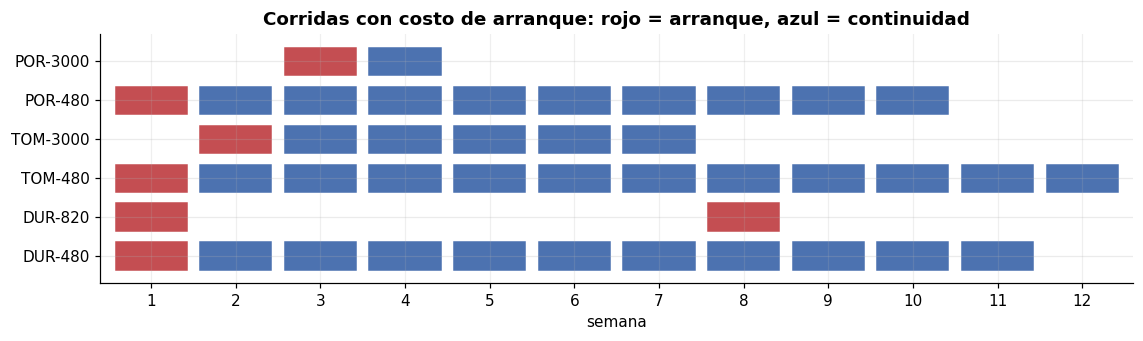

In [8]:
# el mapa de corridas, que es donde se ve la continuidad
fig, ax = plt.subplots(figsize=(10.5, 3.2))
for k, i in enumerate(SKUS):
    for t in T:
        enc = round(v_arr["y"][i, t].X) > 0.5
        es_arr = round(v_arr["alfa"][i, t].X) > 0.5
        if enc:
            ax.add_patch(plt.Rectangle((t - 0.42, k - 0.35), 0.84, 0.7,
                                       color="#c44e52" if es_arr else "#4c72b0"))
ax.set_xlim(0.4, len(T) + 0.6)
ax.set_ylim(-0.7, len(SKUS) - 0.3)
ax.set_yticks(range(len(SKUS)))
ax.set_yticklabels(SKUS)
ax.set_xticks(T)
ax.set_xlabel("semana")
ax.set_title("Corridas con costo de arranque: rojo = arranque, azul = continuidad")
ax.grid(axis="x", alpha=0.2)
figura(fig, "clsp_arranques")
plt.show()

## 6. La lección central: el big-M que deja de ser válido

Este es el punto del cuaderno. Se resuelve **la misma configuración** dos
veces, cambiando **una sola línea**: qué cota se usa en `x_it ≤ M_it y_it`.

* **Cota válida**: `big_M(i, t, con_backlog=True)`. Admite que cualquier
  demanda del horizonte pueda estar pendiente.
* **Cota inválida**: `big_M(i, t, con_backlog=False)`, es decir, la del
  cuaderno 02, heredada sin volver a mirarla. Afirma que en `t` nunca se
  produce más que la demanda de `t` en adelante, lo que con backlog es
  sencillamente falso.

Para descartar cualquier duda se resuelve también con `M = 10⁶`, que es
innegablemente válido y sirve de árbitro.

**Qué hay que mirar:** no el mensaje de error —no lo va a haber—, sino el
valor del objetivo.

In [9]:
filas = []
for etiqueta, kw in [("cota VÁLIDA (con_backlog=True)", dict(cota_backlog="valida")),
                     ("cota INVÁLIDA (heredada del cuad. 02)",
                      dict(cota_backlog="invalida")),
                     ("árbitro: big-M = 1e6", dict(big_M_generico=1e6))]:
    m_, v_ = clsp(**BASE, **kw, tiempo_limite=180.0)
    fila = informar(etiqueta, m_, v_)
    fila["M_medio"] = float(np.mean(list(v_["M"].values())))
    filas.append(fila)
trampa = pd.DataFrame(filas)
print()
print(trampa[["modelo", "estado", "objetivo", "cota", "gap_%", "setups",
              "M_medio"]].to_string(index=False, float_format=lambda v: f"{v:,.2f}"))

z_val = float(trampa.loc[0, "objetivo"])
z_inv = float(trampa.loc[1, "objetivo"])
z_arb = float(trampa.loc[2, "objetivo"])
print(f"\n  óptimo verdadero (cota válida)   : {z_val:>14,.0f} CLP")
print(f"  árbitro con big-M = 1e6          : {z_arb:>14,.0f} CLP  "
      f"(coincide: {abs(z_arb - z_val) < 1e-3})")
print(f"  'óptimo' con la cota inválida    : {z_inv:>14,.0f} CLP")
print(f"  sobrecosto silencioso            : {z_inv - z_val:>14,.0f} CLP "
      f"({100*(z_inv - z_val)/z_val:.4f} %)")
print("\n  Los TRES modelos terminaron en estado OPTIMAL con gap 0 %.")
print("  Ninguno emitio una advertencia. El del medio simplemente contesta")
print("  otra pregunta: la de un problema mas chico que el que se queria")
print("  resolver.")

cota VÁLIDA (con_backlog=True)         OPTIMAL    obj     16,148,005 | 30 setups | gap raíz  63.9 % |  336 var (72 bin) |   1.9 s


cota INVÁLIDA (heredada del cuad. 02)  OPTIMAL    obj     16,152,894 | 30 setups | gap raíz  50.5 % |  336 var (72 bin) |   0.9 s


árbitro: big-M = 1e6                   OPTIMAL    obj     16,148,005 | 30 setups | gap raíz  98.1 % |  336 var (72 bin) |   1.8 s

                               modelo  estado      objetivo          cota  gap_%  setups      M_medio
       cota VÁLIDA (con_backlog=True) OPTIMAL 16,148,004.55 16,148,004.55   0.00      30     4,945.16
cota INVÁLIDA (heredada del cuad. 02) OPTIMAL 16,152,893.78 16,152,893.78   0.00      30     4,066.34
                 árbitro: big-M = 1e6 OPTIMAL 16,148,004.55 16,148,004.55   0.00      30 1,000,000.00

  óptimo verdadero (cota válida)   :     16,148,005 CLP
  árbitro con big-M = 1e6          :     16,148,005 CLP  (coincide: True)
  'óptimo' con la cota inválida    :     16,152,894 CLP
  sobrecosto silencioso            :          4,889 CLP (0.0303 %)

  Los TRES modelos terminaron en estado OPTIMAL con gap 0 %.
  Ninguno emitio una advertencia. El del medio simplemente contesta
  otra pregunta: la de un problema mas chico que el que se queria
  resolver.

### Por qué la diferencia es *chica* y eso la hace peor

El sobrecosto es de 4 889 CLP sobre 16 millones: **0,03 %**. Si fuera del
30 % alguien lo notaría. Al 0,03 % pasa por ruido numérico, por versión del
solver, por semilla. Se firma el informe y nadie vuelve a mirarlo.

Los tres síntomas que **no** aparecen y por eso hay que buscar a propósito:

1. No hay infactibilidad. La cota recorta soluciones, pero el óptimo
   verdadero no es la única solución factible: quedan muchas otras.
2. No hay gap. El solver cierra al 0 % contra la cota inferior **de su
   propio modelo**, que es el modelo recortado. Peor aún: la formulación
   inválida **se ve mejor** en la métrica con la que solemos juzgar
   formulaciones. Su gap en la raíz es 50,5 % contra 63,9 % del modelo
   correcto, y resuelve en menos de la mitad del tiempo. Por supuesto: es un
   poliedro más chico. Un gap en la raíz bajo es evidencia de una buena
   formulación **solo si la formulación es válida**; si no, es evidencia de
   que se recortó algo.
3. No hay advertencia. Gurobi no tiene forma de saber que la constante que se
   le pasó no es válida: para él es un dato.

La única defensa es metodológica, y son dos hábitos:

* **Escribir por qué cada big-M es válido**, no solo cuál es. Si el argumento
  dice "lo anterior ya fue servido", entonces la cota depende de que no haya
  backlog, y eso hay que dejarlo en el código —por ejemplo, en el nombre del
  parámetro.
* **Contrastar contra una cota tonta pero incuestionable.** Resolver una vez
  con `M = 10⁶` cuesta segundos y detecta exactamente este error. Es la misma
  prueba con la que se encontró.

Comprobémoslo sobre el plan: ¿cuántos pares (i, t) del plan **óptimo
verdadero** violan la cota inválida? Cada uno es una solución que la
formulación recortada nunca pudo considerar.

In [10]:
m_val, v_val = clsp(**BASE, cota_backlog="valida", tiempo_limite=180.0)
recortados = []
for i in SKUS:
    for t in T:
        xv = v_val["x"][i, t].X
        M_inv = big_M(i, t, con_backlog=False)
        if xv > M_inv + 1e-6:
            recortados.append({"sku": i, "t": t, "x_optimo": xv,
                               "M_invalido": M_inv,
                               "exceso": xv - M_inv})
rec = pd.DataFrame(recortados)
print(f"Pares (i, t) del plan optimo que la cota invalida prohibe: {len(rec)}\n")
if len(rec):
    print(rec.to_string(index=False, float_format=lambda v: f"{v:,.1f}"))
    print("\nEsas son las cajas que la formulacion recortada no podia producir.")
    print("El solver, obediente, encontro el mejor plan SIN ellas, y lo llamo")
    print("optimo. Lo era: de otro problema.")
else:
    print("Ninguno en este plan: el recorte actuo antes, sobre otras soluciones")
    print("intermedias. El sobrecosto del objetivo es la prueba de que actuo.")

Pares (i, t) del plan optimo que la cota invalida prohibe: 1

     sku  t  x_optimo  M_invalido  exceso
POR-3000  8     591.0       528.0    63.0

Esas son las cajas que la formulacion recortada no podia producir.
El solver, obediente, encontro el mejor plan SIN ellas, y lo llamo
optimo. Lo era: de otro problema.


## 7. Comprobación

In [11]:
print("Comprobación:")
ok = []
ok.append(verificar(float(esc.loc[0, "objetivo"]), 16_457_114.0,
                    "básico (CLP)", tol=1e-5))
ok.append(verificar(float(esc.loc[1, "objetivo"]), 16_247_378.0,
                    "+ horas extra (CLP)", tol=1e-5))
ok.append(verificar(float(esc.loc[2, "objetivo"]), 15_772_683.0,
                    "+ backlog (CLP)", tol=1e-5))
ok.append(verificar(float(esc.loc[3, "objetivo"]), 20_100_279.0,
                    "+ stock seg., lead time e inv. final (CLP)", tol=1e-5))
ok.append(verificar(int(esc.loc[2, "setups"]), 32, "setups con backlog", tol=1e-9))
ok.append(verificar(z_val, 16_148_005.0, "óptimo con cota válida (CLP)", tol=1e-5))
ok.append(verificar(z_inv, 16_152_894.0, "'óptimo' con cota inválida (CLP)", tol=1e-5))
ok.append(verificar(int(arrq.loc[0, "setups"]), 30, "setups sin start-up", tol=1e-9))
ok.append(verificar(int(arrq.loc[1, "setups"]), 43, "setups con start-up", tol=1e-9))
ok.append(verificar(int(arrq.loc[1, "arranques"]), 7, "arranques con start-up", tol=1e-9))
print(f"\n{sum(ok)}/{len(ok)} comprobaciones correctas")

assert z_inv > z_val + 1e-6, \
    "la cota invalida DEBE dar un costo mayor: ese es el sintoma"
assert abs(z_arb - z_val) < 1e-3, \
    "el arbitro con big-M generico debe coincidir con la cota valida"
assert trampa.loc[1, "estado"] == "OPTIMAL", \
    "el sintoma es justamente que el modelo malo dice OPTIMAL"
assert int(arrq.loc[1, "setups"]) > int(arrq.loc[0, "setups"]), \
    "el costo de arranque debe aumentar las preparaciones, no reducirlas"
assert m_sinb.Status == GRB.INFEASIBLE, \
    "el stock de seguridad duro SIN backlog deberia ser infactible aqui"
assert m_duro.ObjVal > float(esc.loc[3, "objetivo"]), \
    "el stock de seguridad duro no puede ser mas barato que el blando"

tabla(esc, "clsp_ext_escalera")
tabla(arrq, "clsp_ext_arranque")
tabla(trampa, "clsp_ext_bigM_backlog")
resumen({"basico": float(esc.loc[0, "objetivo"]),
         "horas_extra": float(esc.loc[1, "objetivo"]),
         "backlog": float(esc.loc[2, "objetivo"]),
         "ss_lead_invfinal": float(esc.loc[3, "objetivo"]),
         "optimo_cota_valida": z_val,
         "optimo_cota_invalida": z_inv,
         "sobrecosto_silencioso": z_inv - z_val,
         "setups_sin_startup": int(arrq.loc[0, "setups"]),
         "setups_con_startup": int(arrq.loc[1, "setups"]),
         "arranques_con_startup": int(arrq.loc[1, "arranques"])},
        "resumen_clsp_extensiones")
print("Guardado en resultados/")

Comprobación:
  [  OK  ] básico (CLP): obtenido 16,457,113.8652 | referencia 16,457,114.0000 | dif. relativa 8.19e-09
  [  OK  ] + horas extra (CLP): obtenido 16,247,378.0403 | referencia 16,247,378.0000 | dif. relativa 2.48e-09
  [  OK  ] + backlog (CLP): obtenido 15,772,683.1442 | referencia 15,772,683.0000 | dif. relativa 9.14e-09
  [  OK  ] + stock seg., lead time e inv. final (CLP): obtenido 20,100,279.4572 | referencia 20,100,279.0000 | dif. relativa 2.27e-08
  [  OK  ] setups con backlog: obtenido 32.0000 | referencia 32.0000 | dif. relativa 0.00e+00
  [  OK  ] óptimo con cota válida (CLP): obtenido 16,148,004.5545 | referencia 16,148,005.0000 | dif. relativa 2.76e-08
  [  OK  ] 'óptimo' con cota inválida (CLP): obtenido 16,152,893.7764 | referencia 16,152,894.0000 | dif. relativa 1.38e-08
  [  OK  ] setups sin start-up: obtenido 30.0000 | referencia 30.0000 | dif. relativa 0.00e+00
  [  OK  ] setups con start-up: obtenido 43.0000 | referencia 43.0000 | dif. relativa 0.00e+00
  

---

## Para llevarse

1. **El big-M ajustado no es una propiedad del modelo: es una propiedad de
   los supuestos.** Cambió un supuesto (se admite backlog) y la cota dejó de
   ser válida. Heredarla sin revisarla produce un modelo que responde
   `OPTIMAL` a otra pregunta.
2. **El error no se detecta mirando la salida del solver.** Estado óptimo,
   gap cero, sin advertencias, y 4 889 CLP de más. Se detecta contrastando
   contra una cota tonta e incuestionable (`M = 10⁶`), o leyendo el
   argumento de validez.
3. **Comparar extensiones exige la misma instancia.** Los cuatro escalones
   difieren en una bandera cada uno; por eso la diferencia de costo es
   atribuible al modelo.
4. **No todas las extensiones abaratan.** Horas extra y backlog bajan el
   costo; stock de seguridad y lead time lo suben en 4,3 millones. Un informe
   que muestra solo las dos primeras está vendiendo un ahorro irreal.
5. **"Infactible" es información.** El stock de seguridad duro sin backlog no
   tiene solución en esta planta, y el IIS dice exactamente qué restricciones
   se contradicen. Eso es un hallazgo de capacidad, no un fracaso del modelo,
   y es distinto de "el solver no encontró nada en el tiempo disponible".
6. **El costo de arranque cambia el signo de la intuición.** Agrega un costo
   y *aumenta* el número de preparaciones, porque premia no apagar. Un modelo
   que solo cobra setup no distingue doce lotes sueltos de doce seguidos.

## Ejercicios

1. Multiplique por 10 el costo de backlog de todos los SKU y vuelva a
   resolver el escalón 3. ¿A partir de qué múltiplo el modelo deja de diferir
   demanda? Ese número es la penalización que la planta debería declarar si
   no quiere que el modelo difiera nunca.
2. Resuelva el escalón 3 con `cota_backlog="invalida"` y con `"valida"`, y
   compare **los planes**, no los totales: ¿en qué semanas y para qué SKU
   difieren? Explique la diferencia con la tabla de la sección 6.
3. La cota inválida da un costo mayor. Construya un argumento de por qué
   **nunca** puede dar uno menor, y diga qué habría que concluir si en otra
   instancia lo diera.
4. Con `stock_seguridad="blando"` y `penal_ss` creciente (1, 5, 20, 100),
   grafique el déficit total de cobertura contra la penalización. ¿A partir
   de qué valor el blando se comporta igual que el duro? ¿Y qué pasa cuando
   el duro es infactible?
5. Declare `alfa` como variable continua en `[0,1]` en vez de binaria.
   Compruebe que el óptimo no cambia y compare el número de nodos. Explique
   por qué la relajación es exacta en este caso concreto.